In [1]:
import sys
print(sys.executable)

/opt/anaconda3/envs/ocean/bin/python


In [149]:
# Import necessary libraries
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import dates as mdates
import copernicusmarine
import warnings
from matplotlib.patches import Patch
warnings.filterwarnings('ignore')  # Suppress warnings for cleaner output
from datetime import datetime
import calendar
from pathlib import Path
import os
from getpass import getpass
import pandas as pd

In [150]:
username = input("Copernicus username: ").strip()
password = getpass("Copernicus password: ")

# Login once (session/config is reused by subset calls)
copernicusmarine.login(username=username, password=password)
netcdf3_compatible=True

INFO - 2026-06-20T10:15:54Z - Downloading Copernicus Marine data requires a Copernicus Marine username and password, sign up for free at: https://data.marine.copernicus.eu/register


Copernicus Marine username:Copernicus Marine password:File /Users/ej/.copernicusmarine/.copernicusmarine-credentials already exists, overwrite it ? [y/N]:

ERROR - 2026-06-20T10:16:25Z - Abort
INFO - 2026-06-20T10:16:25Z - No configuration file have been modified.


In [151]:
# DEFINE REQUEST

# small box around Øresund
lon_min = 12.0
lon_max = 13.2
lat_min = 55.3
lat_max = 56.2

request = {
    "dataset_id": "cmems_mod_glo_phy-thetao_anfc_0.083deg_P1D-m",
    
    "variables": ["thetao"],  # temperature (all depths)
    
    "minimum_longitude": lon_min,
    "maximum_longitude": lon_max,
    "minimum_latitude": lat_min,
    "maximum_latitude": lat_max,
    
    "start_datetime": "2026-06-01",
    "end_datetime": "2026-06-30",
    
    
    "output_directory": "Data",
    "overwrite": True,
}

In [152]:
# DOWNLOAD DATA
copernicusmarine.subset(
    **request,
    output_filename="copernicus_june_2026.nc"
)

INFO - 2026-06-20T10:16:26Z - Selected dataset version: "202406"
INFO - 2026-06-20T10:16:26Z - Selected dataset part: "default"
WARNING - 2026-06-20T10:16:26Z - Some of your subset selection [2026-06-01 00:00:00+00:00, 2026-06-30 00:00:00+00:00] for the time dimension exceed the dataset coordinates [2022-06-01 00:00:00+00:00, 2026-06-29 00:00:00+00:00]


  0%|          | 0/41 [00:00<?, ?it/s]

ResponseSubset(file_path=PosixPath('Data/copernicus_june_2026.nc'), output_directory=PosixPath('Data'), filename='copernicus_june_2026.nc', file_size=0.9261679389312977, data_transfer_size=435.73935877862596, variables=['thetao'], coordinates_extent=[GeographicalExtent(minimum=12.0, maximum=13.166671752929688, unit='degrees_east', coordinate_id='longitude'), GeographicalExtent(minimum=55.333343505859375, maximum=56.16667175292969, unit='degrees_north', coordinate_id='latitude'), TimeExtent(minimum='2026-06-01T00:00:00+00:00', maximum='2026-06-29T00:00:00+00:00', unit='iso8601', coordinate_id='time'), GeographicalExtent(minimum=0.49402499198913574, maximum=5727.9169921875, unit='m', coordinate_id='depth')], status=<StatusCode.SUCCESS: '000'>, message=<StatusMessage.SUCCESS: 'The request was successful.'>, file_status=<FileStatus.OVERWRITTEN: 'OVERWRITTEN'>)

In [153]:
# LOAD DATA
ds = xr.open_dataset("Data/copernicus_june_2026.nc")

print(ds)  # ALWAYS check structure

<xarray.Dataset> Size: 958kB
Dimensions:    (depth: 50, latitude: 11, longitude: 15, time: 29)
Coordinates:
  * depth      (depth) float32 200B 0.494 1.541 2.646 ... 5.275e+03 5.728e+03
  * latitude   (latitude) float32 44B 55.33 55.42 55.5 ... 56.0 56.08 56.17
  * longitude  (longitude) float32 60B 12.0 12.08 12.17 ... 13.0 13.08 13.17
  * time       (time) datetime64[ns] 232B 2026-06-01 2026-06-02 ... 2026-06-29
Data variables:
    thetao     (time, depth, latitude, longitude) float32 957kB ...
Attributes:
    Conventions:               CF-1.8
    area:                      Global
    contact:                   https://marine.copernicus.eu/contact
    credit:                    E.U. Copernicus Marine Service Information (CM...
    institution:               Mercator Ocean International
    licence:                   http://marine.copernicus.eu/services-portfolio...
    producer:                  CMEMS - Global Monitoring and Forecasting Centre
    references:                http://ma

In [154]:
# EXTRACT YOUR POINT
area = ds  # full box

# --- STEP 1: LIMIT DEPTH RANGE FIRST ---
# Only keep realistic shelf depths (Øresund is shallow)
ds_shallow = ds.where(ds["depth"] < 100, drop=False)

# --- STEP 2: EXTRACT SST (same as before) ---
sst = ds_shallow["thetao"].sel(depth=0, method="nearest")

# --- STEP 3: EXTRACT SBT (safe version) ---
sbt = ds_shallow["thetao"].ffill(dim="depth").isel(depth=-1)

# --- STEP 4: SPATIAL AVERAGE ---
sst_mean = sst.mean(dim=["latitude", "longitude"])
sbt_mean = sbt.mean(dim=["latitude", "longitude"], skipna=True)


In [155]:
# CONVERT TO DATAFRAME
df = pd.DataFrame({
    "time": ds["time"].values,
    "SST": sst_mean.values,
    "SBT": sbt_mean.values
})

df["time"] = pd.to_datetime(df["time"])
df = df.set_index("time")

# Convert Kelvin → Celsius if needed
if df["SST"].mean() > 100:
    df["SST"] = df["SST"] - 273.15
    df["SBT"] = df["SBT"] - 273.15

print(df.head())


                  SST        SBT
time                            
2026-06-01  15.220183  13.642214
2026-06-02  15.302194  13.638651
2026-06-03  15.124777  13.585160
2026-06-04  14.964883  13.602017
2026-06-05  15.133744  13.753090


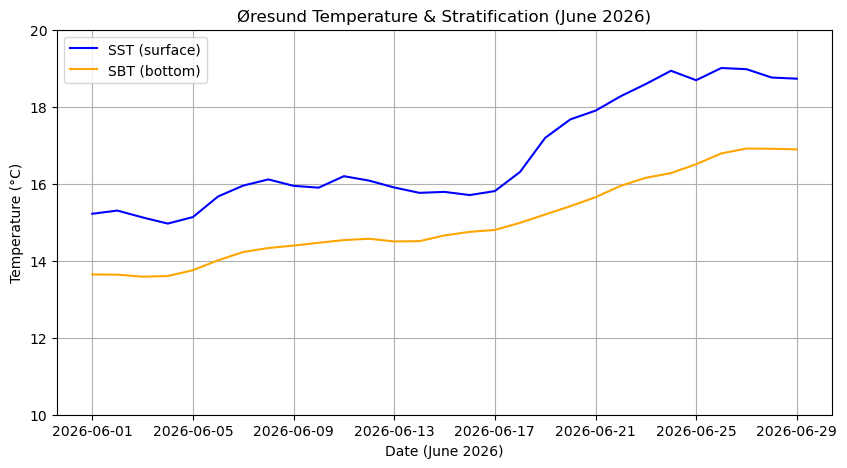

In [156]:
plt.figure(figsize=(10,5))

# SST and SBT
plt.plot(df.index, df["SST"], label="SST (surface)", color="blue")
plt.plot(df.index, df["SBT"], label="SBT (bottom)", color="orange")

plt.ylim(10, 20)

plt.xlabel("Date (June 2026)")
plt.ylabel("Temperature (°C)")

plt.title("Øresund Temperature & Stratification (June 2026)")

plt.legend()
plt.grid()

plt.show()

In [157]:

print(df.min())
print(df.max())


SST    14.964883
SBT    13.585160
dtype: float32
SST    19.005377
SBT    16.914526
dtype: float32


In [158]:
aml = pd.read_excel("/Users/ej/Desktop/Applied Ocean Observation Technologies/AML/aml_2026_sst_sbt.xlsx")

In [159]:
print(aml.head())
print(aml.columns)

                  time  temp_surface  temp_bottom
0  2026-06-10 12-50-12     15.609118    14.266222
1  2026-06-10 10-25-21     15.789870     7.464588
2  2026-06-09 08-12-48     16.091000     7.266850
3  2026-06-09 10-26-13     14.891579    10.813526
4  2026-06-11 07-18-21     15.832269     9.769941
Index(['time', 'temp_surface', 'temp_bottom'], dtype='object')


In [160]:
# Split date and time
aml["time"] = aml["time"].str.split(" ")

# Rebuild properly
aml["time"] = aml["time"].apply(
    lambda x: x[0] + " " + x[1].replace("-", ":")
)

# Convert safely
aml["time"] = pd.to_datetime(aml["time"])
aml = aml.set_index("time")

In [161]:
aml = aml.rename(columns={
    "temp_surface": "SST_aml",
    "temp_bottom": "SBT_aml"
})

# Daily average
aml_daily = aml.resample("D").mean()

# Merge
df_all = df.join(aml_daily, how="left")


In [162]:
print(aml.head())

                       SST_aml    SBT_aml
time                                     
2026-06-10 12:50:12  15.609118  14.266222
2026-06-10 10:25:21  15.789870   7.464588
2026-06-09 08:12:48  16.091000   7.266850
2026-06-09 10:26:13  14.891579  10.813526
2026-06-11 07:18:21  15.832269   9.769941


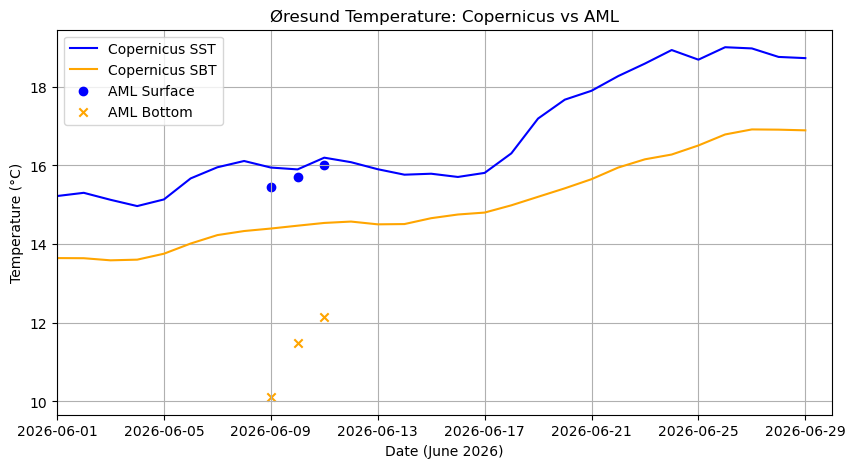

In [163]:
plt.figure(figsize=(10,5))

plt.plot(df_all.index, df_all["SST"], label="Copernicus SST", color="blue")
plt.plot(df_all.index, df_all["SBT"], label="Copernicus SBT", color="orange")

plt.scatter(df_all.index, df_all["SST_aml"], label="AML Surface", color="blue", marker="o")
plt.scatter(df_all.index, df_all["SBT_aml"], label="AML Bottom", color="orange", marker="x")

# 👉 Force full June axis
plt.xlim(pd.Timestamp("2026-06-01"), pd.Timestamp("2026-06-30"))

plt.xlabel("Date (June 2026)")
plt.ylabel("Temperature (°C)")
plt.title("Øresund Temperature: Copernicus vs AML")

plt.legend()
plt.grid()

plt.show()

In [164]:
df_all["strat_aml"] = df_all["SST_aml"] - df_all["SBT_aml"]

plt.figure(figsize=(10,5))

plt.plot(df_all.index, df_all["stratification"], label="Copernicus", linestyle="--")
plt.scatter(df_all.index, df_all["strat_aml"], label="AML", marker="o")

plt.ylabel("ΔT (°C)")
plt.xlabel("Date")
plt.title("Stratification: Copernicus vs AML")

plt.legend()
plt.grid()

plt.show()

KeyError: 'stratification'

<Figure size 1000x500 with 0 Axes>

In [ ]:
bias_sst = (df_all["SST"] - df_all["SST_aml"]).mean()
bias_sbt = (df_all["SBT"] - df_all["SBT_aml"]).mean()

print("SST bias:", bias_sst)
print("SBT bias:", bias_sbt)


SST bias: 0.2901029316123136
SBT bias: 3.2184827217333978


In [ ]:
import numpy as np

rmse_sst = np.sqrt(((df_all["SST"] - df_all["SST_aml"])**2).mean())
rmse_sbt = np.sqrt(((df_all["SBT"] - df_all["SBT_aml"])**2).mean())

print("SST RMSE:", rmse_sst)
print("SBT RMSE:", rmse_sbt)

SST RMSE: 0.327816964492901
SBT RMSE: 3.3149320641003346


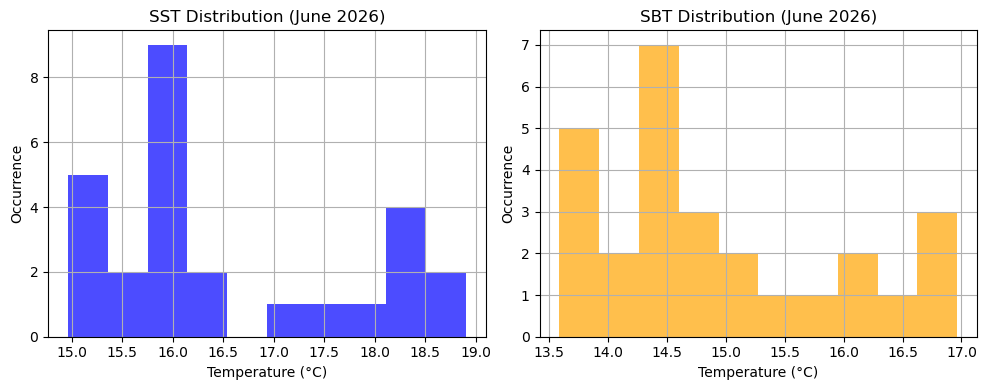

In [ ]:

# Create 1 row, 2 columns
fig, ax = plt.subplots(1, 2, figsize=(10,4))

# --- LEFT: SST ---
ax[0].hist(df["SST"], bins=10, color="blue", alpha=0.7)
ax[0].set_title("SST Distribution (June 2026)")
ax[0].set_xlabel("Temperature (°C)")
ax[0].set_ylabel("Occurrence")
ax[0].grid()

# --- RIGHT: SBT ---
ax[1].hist(df["SBT"], bins=10, color="orange", alpha=0.7)
ax[1].set_title("SBT Distribution (June 2026)")
ax[1].set_xlabel("Temperature (°C)")
ax[1].set_ylabel("Occurrence")
ax[1].grid()

plt.tight_layout()
plt.show()

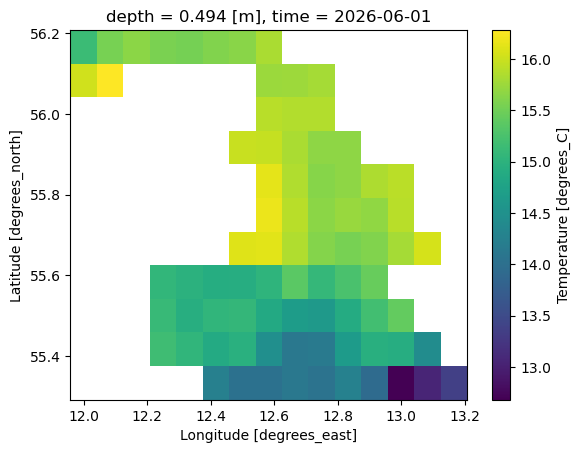

In [ ]:
ds["thetao"].isel(time=0, depth=0).plot()

In [ ]:
#Copernicus Marine Global Ocean Analysis and Forecast data (0.083° resolution) was extracted for the Øresund region (12.0–13.2°E, 55.3–56.2°N) for June 2026

In [ ]:
copernicusmarine.subset(
    dataset_id="cmems_mod_glo_phy-thetao_anfc_0.083deg_P1D-m",
    variables=["thetao"],
    minimum_longitude=lon_min,
    maximum_longitude=lon_max,
    minimum_latitude=lat_min,
    maximum_latitude=lat_max,
    start_datetime="2022-06-01",
    end_datetime="2025-06-30",
    output_filename="copernicus_2022_2025.nc",
    netcdf3_compatible=True
)

INFO - 2026-06-18T09:03:46Z - Selected dataset version: "202406"
INFO - 2026-06-18T09:03:46Z - Selected dataset part: "default"


  0%|          | 0/201 [00:00<?, ?it/s]

ResponseSubset(file_path=PosixPath('copernicus_2022_2025.nc'), output_directory=PosixPath('.'), filename='copernicus_2022_2025.nc', file_size=35.469106870229005, data_transfer_size=1960.8271145038168, variables=['thetao'], coordinates_extent=[GeographicalExtent(minimum=12.0, maximum=13.166671752929688, unit='degrees_east', coordinate_id='longitude'), GeographicalExtent(minimum=55.333343505859375, maximum=56.16667175292969, unit='degrees_north', coordinate_id='latitude'), TimeExtent(minimum='2022-06-01T00:00:00+00:00', maximum='2025-06-30T00:00:00+00:00', unit='iso8601', coordinate_id='time'), GeographicalExtent(minimum=0.49402499198913574, maximum=5727.9169921875, unit='m', coordinate_id='depth')], status='000', message='The request was successful.', file_status='DOWNLOADED')

In [ ]:
ds_hist = xr.open_dataset("copernicus_2022_2025.nc")

In [ ]:
# Surface
sst_hist = ds_hist["thetao"].sel(depth=0, method="nearest")

# Bottom (correct way!)
sbt_hist = ds_hist["thetao"].ffill(dim="depth").isel(depth=-1)

sst_hist_mean = sst_hist.mean(dim=["latitude", "longitude"], skipna=True)
sbt_hist_mean = sbt_hist.mean(dim=["latitude", "longitude"], skipna=True)

In [ ]:
import pandas as pd

df_hist = pd.DataFrame({
    "time": ds_hist["time"].values,
    "SST": sst_hist_mean.values,
    "SBT": sbt_hist_mean.values
})

df_hist["time"] = pd.to_datetime(df_hist["time"])
df_hist = df_hist.set_index("time")

In [ ]:
if df_hist["SST"].mean() > 100:
    df_hist["SST"] -= 273.15
    df_hist["SBT"] -= 273.15

In [ ]:
df_hist_june = df_hist[df_hist.index.month == 6]

In [ ]:
climatology = df_hist_june.groupby(df_hist_june.index.day).mean()

In [ ]:
df["day"] = df.index.day

In [ ]:
df["SST_anomaly"] = df.apply(
    lambda row: row["SST"] - climatology.loc[row["day"], "SST"],
    axis=1
)

df["SBT_anomaly"] = df.apply(
    lambda row: row["SBT"] - climatology.loc[row["day"], "SBT"],
    axis=1
)

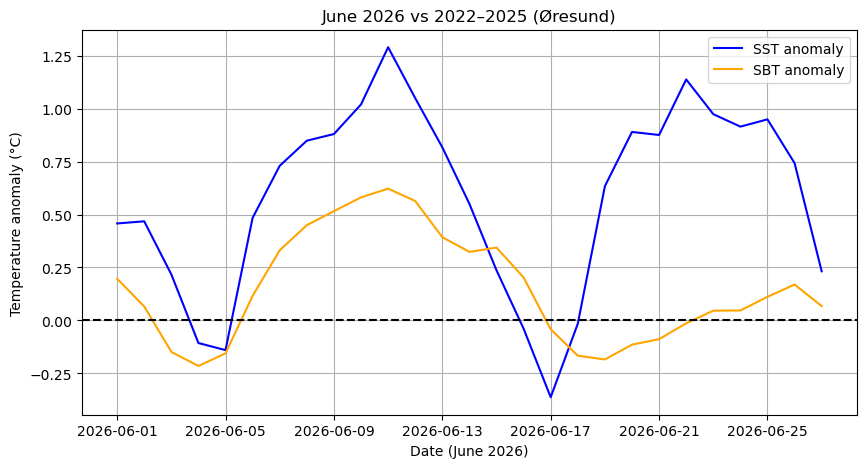

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(df.index, df["SST_anomaly"], label="SST anomaly", color="blue")
plt.plot(df.index, df["SBT_anomaly"], label="SBT anomaly", color="orange")

plt.axhline(0, color="black", linestyle="--")

plt.xlabel("Date (June 2026)")
plt.ylabel("Temperature anomaly (°C)")
plt.title("June 2026 vs 2022–2025 (Øresund)")

plt.legend()
plt.grid()
plt.show()

In [ ]:
climatology_std = df_hist_june.groupby(df_hist_june.index.day).std()

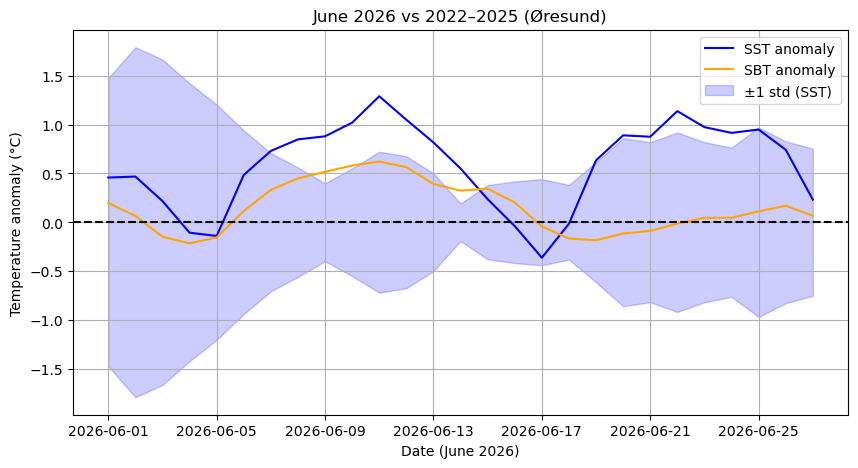

In [ ]:
plt.figure(figsize=(10,5))

# anomaly lines
plt.plot(df.index, df["SST_anomaly"], label="SST anomaly", color="blue")
plt.plot(df.index, df["SBT_anomaly"], label="SBT anomaly", color="orange")

# match std to available days
clim_std_subset = climatology_std.loc[df.index.day]

plt.fill_between(
    df.index,
    -clim_std_subset["SST"].values,
    clim_std_subset["SST"].values,
    color="blue",
    alpha=0.2,
    label="±1 std (SST)"
)

plt.axhline(0, color="black", linestyle="--")

plt.xlabel("Date (June 2026)")
plt.ylabel("Temperature anomaly (°C)")
plt.title("June 2026 vs 2022–2025 (Øresund)")

plt.legend()
plt.grid()

plt.show()

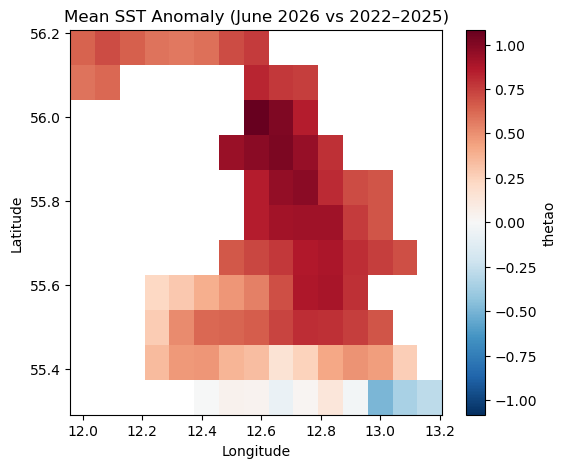

In [ ]:
# --- SST MAP ANALYSIS ---

# Extract surface temperature (2026)
sst_map_2026 = ds["thetao"].sel(depth=0, method="nearest")

# Extract surface temperature (historical)
sst_map_hist = ds_hist["thetao"].sel(depth=0, method="nearest")

# Keep only June for historical
sst_map_hist_june = sst_map_hist.sel(time=sst_map_hist["time.month"] == 6)

# Build daily climatology (per grid cell)
sst_clim_map = sst_map_hist_june.groupby("time.day").mean("time")

# Compute anomaly for each day
sst_anomaly_map = sst_map_2026.groupby("time.day") - sst_clim_map

# Compute mean anomaly over June
sst_anomaly_mean_map = sst_anomaly_map.mean(dim="time")

# Plot
plt.figure(figsize=(6,5))
sst_anomaly_mean_map.plot(cmap="RdBu_r")

plt.title("Mean SST Anomaly (June 2026 vs 2022–2025)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

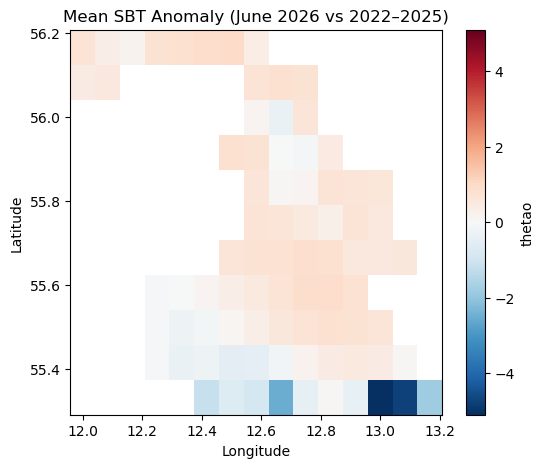

In [ ]:
# --- SBT MAP ANALYSIS ---

# Extract bottom temperature (2026)
sbt_map_2026 = ds["thetao"].ffill(dim="depth").isel(depth=-1)

# Extract bottom temperature (historical)
sbt_map_hist = ds_hist["thetao"].ffill(dim="depth").isel(depth=-1)

# Keep only June for historical
sbt_map_hist_june = sbt_map_hist.sel(time=sbt_map_hist["time.month"] == 6)

# Build daily climatology
sbt_clim_map = sbt_map_hist_june.groupby("time.day").mean("time")

# Compute anomaly
sbt_anomaly_map = sbt_map_2026.groupby("time.day") - sbt_clim_map

# Mean anomaly over June
sbt_anomaly_mean_map = sbt_anomaly_map.mean(dim="time")

# Plot
plt.figure(figsize=(6,5))
sbt_anomaly_mean_map.plot(cmap="RdBu_r")

plt.title("Mean SBT Anomaly (June 2026 vs 2022–2025)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

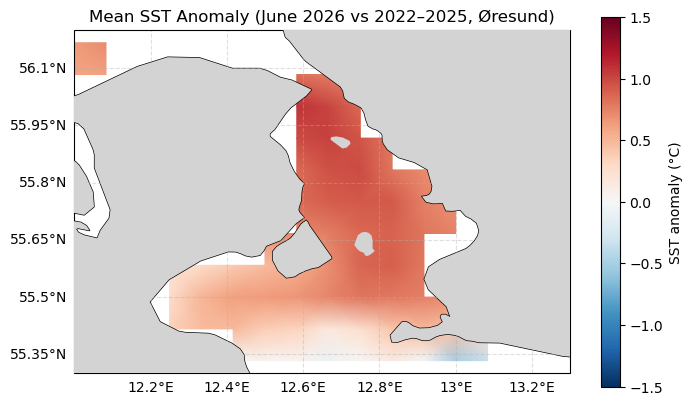

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# --- SETTINGS ---
vmin, vmax = -1.5, 1.5   # symmetric color scale (important!)

# --- CREATE FIGURE ---
fig = plt.figure(figsize=(8,6))
ax = plt.axes(projection=ccrs.PlateCarree())

# --- PLOT DATA (clean version) ---
mesh = ax.pcolormesh(
    sst_anomaly_mean_map["longitude"],
    sst_anomaly_mean_map["latitude"],
    sst_anomaly_mean_map,
    cmap="RdBu_r",
    vmin=vmin,
    vmax=vmax,
    shading="gouraud",   # smooths visual appearance
    transform=ccrs.PlateCarree()
)

# --- COLORBAR ---
cbar = plt.colorbar(mesh, ax=ax, shrink=0.8)
cbar.set_label("SST anomaly (°C)")

# --- ADD LAND + COASTLINES ---
ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=10)
ax.coastlines(resolution="10m", linewidth=1)

# --- FOCUS ON ØRESUND ---
ax.set_extent([12.0, 13.3, 55.3, 56.2], crs=ccrs.PlateCarree())

# --- ADD GRIDLINES (clean style) ---
gl = ax.gridlines(draw_labels=True, linestyle="--", alpha=0.4)
gl.top_labels = False
gl.right_labels = False

# --- TITLE ---
plt.title("Mean SST Anomaly (June 2026 vs 2022–2025, Øresund)")

plt.show()


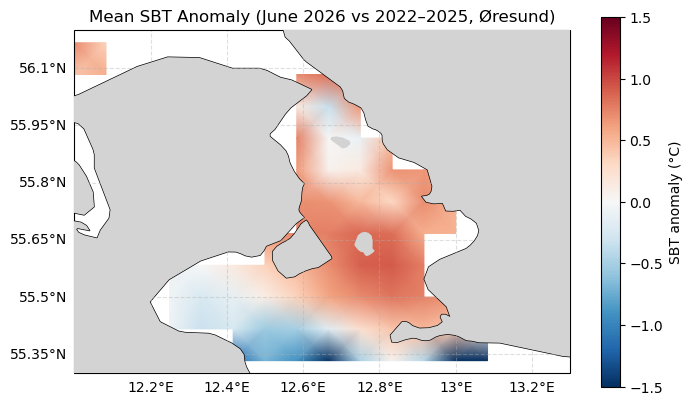

In [ ]:
fig = plt.figure(figsize=(8,6))
ax = plt.axes(projection=ccrs.PlateCarree())

mesh = ax.pcolormesh(
    sbt_anomaly_mean_map["longitude"],
    sbt_anomaly_mean_map["latitude"],
    sbt_anomaly_mean_map,
    cmap="RdBu_r",
    vmin=vmin,
    vmax=vmax,
    shading="gouraud",
    transform=ccrs.PlateCarree()
)

cbar = plt.colorbar(mesh, ax=ax, shrink=0.8)
cbar.set_label("SBT anomaly (°C)")

ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=10)
ax.coastlines(resolution="10m", linewidth=1)

ax.set_extent([12.0, 13.3, 55.3, 56.2], crs=ccrs.PlateCarree())

gl = ax.gridlines(draw_labels=True, linestyle="--", alpha=0.4)
gl.top_labels = False
gl.right_labels = False

plt.title("Mean SBT Anomaly (June 2026 vs 2022–2025, Øresund)")

plt.show()

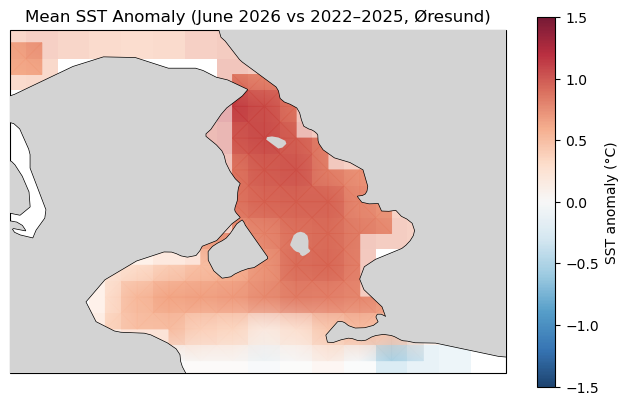

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig = plt.figure(figsize=(8,6))
ax = plt.axes(projection=ccrs.PlateCarree())

# --- 1. Smooth background field ---
smooth = ax.pcolormesh(
    sst_anomaly_mean_map["longitude"],
    sst_anomaly_mean_map["latitude"],
    sst_anomaly_mean_map,
    cmap="RdBu_r",
    vmin=-1.5, vmax=1.5,
    shading="gouraud",
    alpha=0.9,
    transform=ccrs.PlateCarree()
)

# --- 2. Overlay actual grid cells ---
grid = ax.pcolormesh(
    sst_anomaly_mean_map["longitude"],
    sst_anomaly_mean_map["latitude"],
    sst_anomaly_mean_map,
    cmap="RdBu_r",
    vmin=-1.5, vmax=1.5,
    shading="nearest",   # <-- shows the real pixels
    alpha=0.4,
    transform=ccrs.PlateCarree()
)

# --- Colorbar ---
cbar = plt.colorbar(smooth, ax=ax, shrink=0.8)
cbar.set_label("SST anomaly (°C)")

# --- Add land + coastline ---
ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=10)
ax.coastlines(resolution="10m", linewidth=1)

# --- Zoom to Øresund ---
ax.set_extent([12.0, 13.3, 55.3, 56.2], crs=ccrs.PlateCarree())


plt.title("Mean SST Anomaly (June 2026 vs 2022–2025, Øresund)")

plt.show()

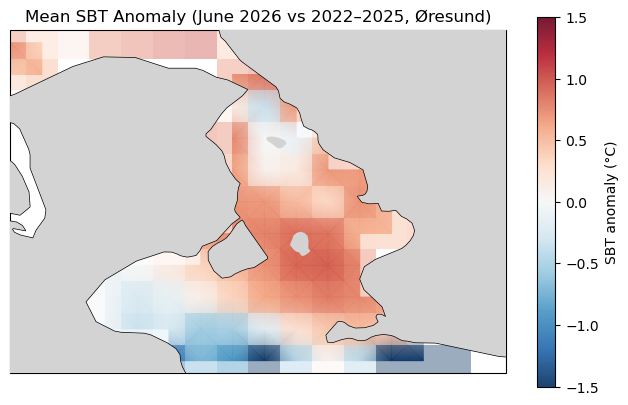

In [ ]:
fig = plt.figure(figsize=(8,6))
ax = plt.axes(projection=ccrs.PlateCarree())

# --- 1. Smooth background field ---
smooth = ax.pcolormesh(
    sbt_anomaly_mean_map["longitude"],
    sbt_anomaly_mean_map["latitude"],
    sbt_anomaly_mean_map,
    cmap="RdBu_r",
    vmin=-1.5, vmax=1.5,
    shading="gouraud",
    alpha=0.9,
    transform=ccrs.PlateCarree()
)

# --- 2. Overlay actual grid cells ---
grid = ax.pcolormesh(
    sbt_anomaly_mean_map["longitude"],
    sbt_anomaly_mean_map["latitude"],
    sbt_anomaly_mean_map,
    cmap="RdBu_r",
    vmin=-1.5, vmax=1.5,
    shading="nearest",   # <-- shows the real pixels
    alpha=0.4,
    transform=ccrs.PlateCarree()
)

# --- Colorbar ---
cbar = plt.colorbar(smooth, ax=ax, shrink=0.8)
cbar.set_label("SBT anomaly (°C)")

# --- Add land + coastline ---
ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=10)
ax.coastlines(resolution="10m", linewidth=1)

# --- Zoom to Øresund ---
ax.set_extent([12.0, 13.3, 55.3, 56.2], crs=ccrs.PlateCarree())


plt.title("Mean SBT Anomaly (June 2026 vs 2022–2025, Øresund)")

plt.show()

In [166]:
# Add day-of-month to your 2026 data
df["day"] = df.index.day

# Compute anomalies using your climatology
df["SST_anomaly"] = df.apply(
    lambda row: row["SST"] - climatology.loc[row["day"], "SST"],
    axis=1
)

df["SBT_anomaly"] = df.apply(
    lambda row: row["SBT"] - climatology.loc[row["day"], "SBT"],
    axis=1
)

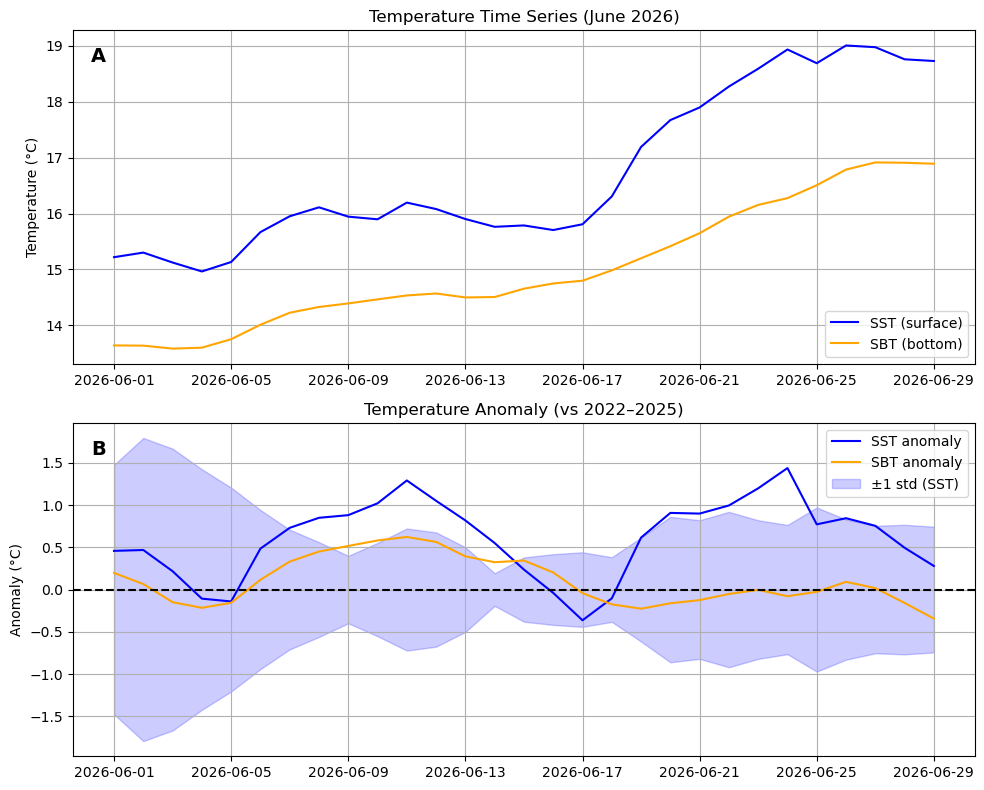

In [170]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# --- FIGURE SETUP ---
fig = plt.figure(figsize=(10,8))

# ======================================================
# ✅ PANEL A — TIME SERIES
# ======================================================
ax1 = plt.subplot(2,1,1)

ax1.plot(df.index, df["SST"], label="SST (surface)", color="blue")
ax1.plot(df.index, df["SBT"], label="SBT (bottom)", color="orange")

ax1.set_ylabel("Temperature (°C)")
ax1.set_title("Temperature Time Series (June 2026)")
ax1.grid()
ax1.legend()

# ✅ ADD LABEL
ax1.text(0.02, 0.95, "A", transform=ax1.transAxes,
         fontsize=14, fontweight="bold", va="top")


# ======================================================
# ✅ PANEL B — ANOMALY
# ======================================================
ax2 = plt.subplot(2,1,2)

ax2.plot(df.index, df["SST_anomaly"], label="SST anomaly", color="blue")
ax2.plot(df.index, df["SBT_anomaly"], label="SBT anomaly", color="orange")

clim_std_subset = climatology_std.loc[df.index.day]

ax2.fill_between(
    df.index,
    -clim_std_subset["SST"].values,
    clim_std_subset["SST"].values,
    color="blue",
    alpha=0.2,
    label="±1 std (SST)"
)

ax2.axhline(0, color="black", linestyle="--")

ax2.set_ylabel("Anomaly (°C)")
ax2.set_title("Temperature Anomaly (vs 2022–2025)")
ax2.grid()
ax2.legend()

# ✅ ADD LABEL
ax2.text(0.02, 0.95, "B", transform=ax2.transAxes,
         fontsize=14, fontweight="bold", va="top")


# ======================================================
# ✅ FINAL TOUCH
# ======================================================
plt.tight_layout()

plt.show()

In [ ]:
print(ds["depth"].values)

[4.940250e-01 1.541375e+00 2.645669e+00 3.819495e+00 5.078224e+00
 6.440614e+00 7.929560e+00 9.572997e+00 1.140500e+01 1.346714e+01
 1.581007e+01 1.849556e+01 2.159882e+01 2.521141e+01 2.944473e+01
 3.443415e+01 4.034405e+01 4.737369e+01 5.576429e+01 6.580727e+01
 7.785385e+01 9.232607e+01 1.097293e+02 1.306660e+02 1.558507e+02
 1.861256e+02 2.224752e+02 2.660403e+02 3.181274e+02 3.802130e+02
 4.539377e+02 5.410889e+02 6.435668e+02 7.633331e+02 9.023393e+02
 1.062440e+03 1.245291e+03 1.452251e+03 1.684284e+03 1.941893e+03
 2.225078e+03 2.533336e+03 2.865703e+03 3.220820e+03 3.597032e+03
 3.992484e+03 4.405224e+03 4.833291e+03 5.274784e+03 5.727917e+03]


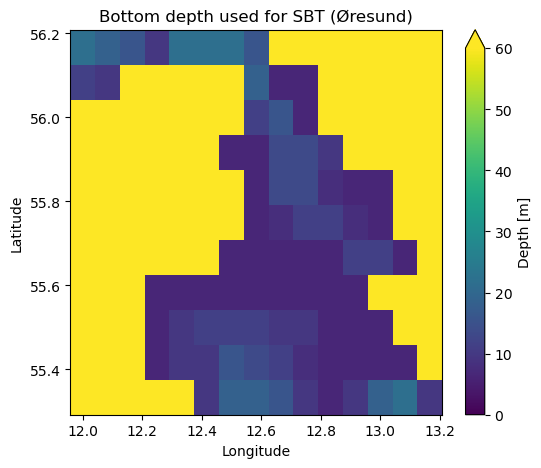

In [ ]:
plt.figure(figsize=(6,5))

bottom_depth_used.plot(
    cmap="viridis",
    vmin=0,     # shallow limit
    vmax=60     # adjust based on your region (~50 m is typical)
)

plt.title("Bottom depth used for SBT (Øresund)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

In [ ]:

print(bottom_depth_used.min().values)
print(bottom_depth_used.max().values)


6.440614223480225
5727.9169921875


In [ ]:
# Remove unrealistic deep values (outside Øresund)
bottom_depth_clean = bottom_depth_used.where(bottom_depth_used < 100)


In [ ]:
depth_min = 5
depth_max = 50

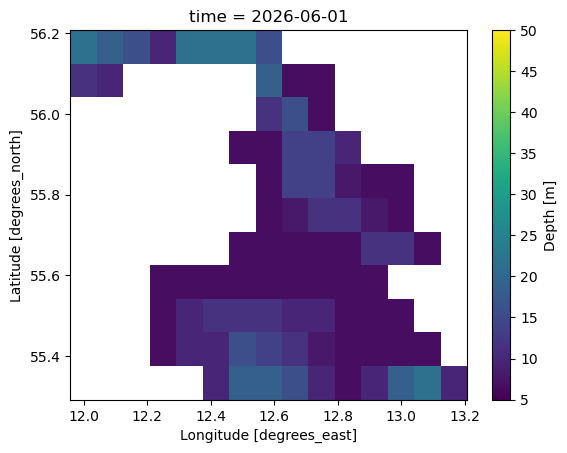

In [ ]:
bottom_depth_clean.plot(
    cmap="viridis",
    vmin=depth_min,
    vmax=depth_max
)

In [ ]:
def plot_bottom_depth(data):
    plt.figure(figsize=(6,5))
    
    data.plot(
        cmap="viridis",
        vmin=depth_min,
        vmax=depth_max
    )
    
    plt.title("Seabed depth (Øresund)")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.show()